In [1]:
import numpy as np
import matplotlib.pyplot as plt
import OptimalBattery.util as ut
import os
import pickle
import PcmPy as pcm
import seaborn as sns
import pandas as pd
import OptimalBattery.evaluate as ev
import Functional_Fusion.atlas_map as am
from Functional_Fusion.dataset import DataSetMDTB
from IndividualParcellation.global_config import *
import OptimalBattery.estimate as es
import Functional_Fusion.dataset as fdata
import cortico_cereb_connectivity.run_model as rm
import cortico_cereb_connectivity.model as model
from collections import defaultdict
import cortico_cereb_connectivity.evaluation as con_ev

Default device set to: cuda


# define atlas and dirs

In [2]:
base_dir = 'Y:/data/'
if not os.path.exists(base_dir):
    base_dir = '/cifs/diedrichsen/data/'

func_fus_dir = os.path.join(base_dir, 'FunctionalFusion')
cerebellum_dir = os.path.join(base_dir, 'Cerebellum')
connectivity_dir = os.path.join(base_dir, 'OptimalBattery', 'connectivity')
#check if the directories exist
if not os.path.exists(connectivity_dir):
    os.makedirs(connectivity_dir)
MDTB_dataset = DataSetMDTB(f'{func_fus_dir}/MDTB')


In [3]:
space = 'SUIT3'
suit_atlas,_= am.get_atlas(atlas_str=space)

data_mdtb_s1_run_suit,info_mdtb_1_run  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='CondRun')
data_mdtb_s1_run_suit[np.isnan(data_mdtb_s1_run_suit)] = 0



data_mdtb_s1_all_suit,info_mdtb_1_all  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='CondAll')
data_mdtb_s1_all_suit[np.isnan(data_mdtb_s1_all_suit)] = 0


data_mdtb_s2_all_suit,info_mdtb_2_all  =MDTB_dataset.get_data(space=space,ses_id='ses-s2',type='CondAll')
data_mdtb_s2_all_suit[np.isnan(data_mdtb_s2_all_suit)] = 0


In [4]:
space ='fs32k'
fs_atlas,_= am.get_atlas(atlas_str=space)
data_mdtb_s1_run_fs,info_mdtb_1_run  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='CondRun')
data_mdtb_s1_run_fs[np.isnan(data_mdtb_s1_run_fs)] = 0

data_mdtb_s1_all_fs,info_mdtb_1_all  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='CondAll')
data_mdtb_s1_all_fs[np.isnan(data_mdtb_s1_all_fs)] = 0

data_mdtb_s2_all_fs,info_mdtb_2_all  =MDTB_dataset.get_data(space=space,ses_id='ses-s2',type='CondAll')
data_mdtb_s2_all_fs[np.isnan(data_mdtb_s2_all_fs)] = 0

In [5]:
data_mdtb_s1_run_fs = ut.recenter_fmri_data(data_mdtb_s1_run_fs,info_mdtb_1_run,task_column_name='cond_name',center_condition='rest')
data_mdtb_s1_all_fs = ut.recenter_fmri_data(data_mdtb_s1_all_fs,info_mdtb_1_all,task_column_name='cond_name',center_condition='rest')
print(data_mdtb_s1_run_fs.shape)
print(data_mdtb_s1_all_fs.shape)

(24, 464, 59518)
(24, 29, 59518)


# Get crossvalidated second moment matrix (GLib)

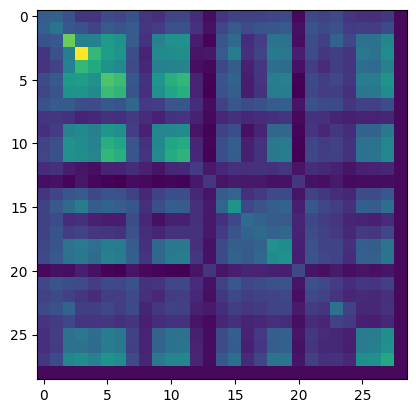

In [6]:
cond_vec = np.tile(np.arange(1, 29 + 1), 16)
part_vec = np.repeat(np.arange(1, 16 + 1), 29)
Gs_list = []
E_list = []
for i in range(data_mdtb_s1_run_fs.shape[0]):
    Gs,E = pcm.util.est_G_crossval(data_mdtb_s1_run_fs[i] , cond_vec, part_vec)
    Gs_list.append(Gs)
    E_list.append(E)

Gs_list = np.stack(Gs_list, 0)
G_Lib = np.mean(Gs_list, axis=0)

plt.imshow(G_Lib)

In [12]:
import OptimalBattery.construct as ct
condition_df= ct.get_condition_indices(info_mdtb_1_run)

In [13]:
def center_matrix(X,axis =0):
    """Center the matrix by subtracting the mean.
    Args:
        X: matrix to center
        axis: Axis along which to center the data
    return:
        X: Centered matrix
    """
    mean = np.nanmean(X, axis=axis, keepdims=True)
    X = X - mean
    return X

def normalize_matrix(X,axis = 0):
    """Normalize the matrix by dividing by the norm.
    Args:
        X: matrix to normalize
        axis: Axis along which to normalize the data
    return:
        X: Normalized matrix
    """
    norm = np.sqrt(np.nansum(X**2, axis=axis, keepdims=True))
    norm = np.where(norm == 0, 1.0, norm)
    X = X / norm
    return X

def average_regressors(run_data, regressor_groups):
    """
    Computes the average of selected regressors efficiently using PyTorch.

    Args:
        run_data (torch.Tensor): Input tensor of shape (subjects, regressors, voxels).
        regressor_groups (list of list of int): A list containing lists of regressor indices to be averaged.
    Returns:
        Ysubset (torch.Tensor): Averaged regressors of shape (subjects, number of tasks, voxels).
    """
    subjects, _, voxels = run_data.shape
    num_groups = len(regressor_groups)
    
    # Pre-allocate output tensor
    result = np.zeros((subjects, num_groups, voxels))
    
    # Compute the average for each group
    for i, indices in enumerate(regressor_groups):
        selected = run_data[:, indices, :]  # Gather the required regressors
        result[:, i, :] = np.nanmean(selected, axis=1)  # Average the selected regressors
    return result



In [30]:
def process_combination(combination, data_train_fs, data_train_suit, 
                        data_test_fs, data_test_suit, 
                        condition_df, localizer_time=8):
    
    # get regressors for training data
    combination_regressors = ct.build_combination_regressors(combination, condition_df=condition_df, localizer_time=localizer_time)
    
    #Prepare training data
    xtrain = average_regressors(data_train_fs, combination_regressors)
    xtrain = center_matrix(xtrain, axis=1)
    xtrain = normalize_matrix(xtrain, axis=1)
    
    ytrain = average_regressors(data_train_suit, combination_regressors)
    ytrain = center_matrix(ytrain, axis=1)
    ytrain = normalize_matrix(ytrain, axis=1)
    
    # prepare test data
    xtest = center_matrix(data_test_fs, axis=1)
    xtest = normalize_matrix(xtest, axis=1)
    
    ytest = center_matrix(data_test_suit, axis=1)
    ytest = normalize_matrix(ytest, axis=1)
    
    return xtrain, ytrain, xtest, ytest

In [27]:
X_atlas = fs_atlas
y_atlas = suit_atlas
train_label_image= []
for hemi in ['L', 'R']:
    train_label_image.append(func_fus_dir + '/Atlases' + f'/tpl-fs32k' + f'/Icosahedron1002.{hemi}.label.gii')
    
def fit_model(xtrain,ytrain,method,alpha_list):
    # initialize training dict
    conn_model_list = []
    # Loop over subjects
    for i in range(xtrain.shape[0]):
        YY  = ytrain[i]
        # get the mean across tessels for cortical data   
        X_atlas.get_parcel(train_label_image, unite_struct = False)

        XX = xtrain[i]
        # get the mean across tessels for cortical data
        XX, labels = fdata.agg_parcels(XX, X_atlas.label_vector,fcn=np.nanmean)

        # Remove Nans
        Y = np.nan_to_num(YY[:,:])
        X = np.nan_to_num(XX[:,:])


        #Definitely subtract intercept across all conditions
        X = (X - X.mean(axis=0))
        Y = (Y - Y.mean(axis=0))


        method = method 

        for la in alpha_list:
        # loop over subjects and train models
            alpha = np.exp(la) # get alpha
            conn_model = getattr(model, method)(alpha)

            # Fit model, get train and validate metrics
            conn_model.fit(X, Y)
            conn_model_list.append(conn_model)

    return conn_model_list


In [28]:
def evaluate_model(xtest,ytest,conn_model_list):
    R_list = []
    # loop over subjects
    for i in range(xtest.shape[0]):
        YY = ytest[i]
        XX = xtest[i]

        # get the vector containing tessel labels
        X_atlas.get_parcel(train_label_image, unite_struct = False)
        
        # get the mean across tessels for cortical data
        XX, labels = fdata.agg_parcels(XX, X_atlas.label_vector,fcn=np.nanmean)

        # Remove Nans
        Y = np.nan_to_num(YY[:,:])
        X = np.nan_to_num(XX[:,:] )

        #Definitely subtract intercept across all conditions
        X = (X - X.mean(axis=0))
        Y = (Y - Y.mean(axis=0))

        fitM = conn_model_list[i]

        # Get model predictions
        Y_pred = fitM.predict(X)
        R,_ = con_ev.calculate_R(Y, Y_pred)
        R_list.append(R)
    return R_list


In [ ]:
battery_sizes = [3,4,5,6,7,8,9,10,12,14,16]
metrics  = ['variance','log_det_mc','variance_mc','inverse_trace_mc']
results_df = pd.DataFrame()

for n_task in battery_sizes:
    print(f"Processing battery size: {n_task}")

    # Generate possible battery combinations for current battery size and evaluate each battery
    D = ct.build_combinations(G_Lib, strategy='random',n_batteries=100,n_tasks=n_task,seed=1,replacement=False)
    D = D.reset_index(drop=True)

    for metric in metrics:
        top_comb = D.iloc[D[metric].idxmax()]['combination']
        xtrain, ytrain, xtest, ytest = process_combination(top_comb, data_mdtb_s1_run_fs, data_mdtb_s1_run_suit,data_mdtb_s2_all_fs, data_mdtb_s2_all_suit, condition_df, localizer_time=8)
        connetivity_list = fit_model(xtrain,ytrain,'L2regression',alpha_list = [8])
        R_list = evaluate_model(xtest,ytest,connetivity_list)
        R = np.mean(R_list)
        #standard error
        R_sem = np.std(R_list)/np.sqrt(len(R_list))

        D_ev = pd.DataFrame()
        D_ev['battery_size'] = [n_task]
        D_ev['metric'] = [metric]
        D_ev['R'] = [R]
        D_ev['R_sem'] = [R_sem]
        

    
        results_df = pd.concat([results_df,D_ev],axis=0)
    

Processing battery size: 3


C:\Users\barafat\Documents\GitHub\cortico_cereb_connectivity\model.py:95: RuntimeWarning: invalid value encountered in divide
  Xs = X / self.scale_
C:\Users\barafat\Documents\GitHub\cortico_cereb_connectivity\model.py:95: RuntimeWarning: invalid value encountered in divide
  Xs = X / self.scale_


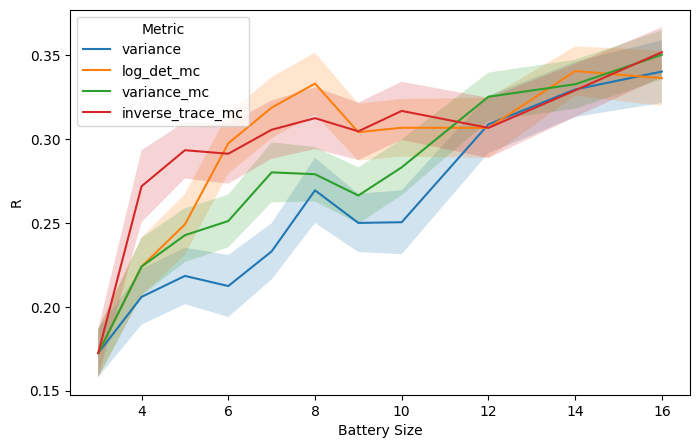

In [ ]:
plt.figure(figsize=(8, 5))
for metric in results_df['metric'].unique():
    subset = results_df[results_df['metric'] == metric]
    plt.plot(subset['battery_size'], subset['R'], label=metric)
    plt.fill_between(subset['battery_size'], subset['R'] - subset['R_sem'], subset['R'] + subset['R_sem'], alpha=0.2)

plt.xlabel('Battery Size')
plt.ylabel('R')
plt.legend(title='Metric')
plt.show()